In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.patches as patches

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/mashob/labaDeforest/deforestation dataset"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

if not os.path.exists(ROOT_PATH):
    raise FileNotFoundError(f" Директория {ROOT_PATH} не найдена. Убедитесь, что данные загружены в Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive/"):
    if "deforestation" in root.lower():
        print(" Найдена папка:", root)

 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/train data
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/train data/deforested
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/train data/non-deforested
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/val data
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/val data/non-deforested
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/val data/deforested
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/test data
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/test data/deforested
 Найдена папка: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/test data/non-deforested


In [ ]:
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

train_dir = os.path.join(ROOT_PATH, 'train data')
validation_dir = os.path.join(ROOT_PATH, 'val data')
test_dir = os.path.join(ROOT_PATH, 'test data')

print(f"Image Width: {IMG_WIDTH}")
print(f"Image Height: {IMG_HEIGHT}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {validation_dir}")
print(f"Test directory: {test_dir}")

Image Width: 224
Image Height: 224
Batch Size: 32
Train directory: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/train data
Validation directory: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/val data
Test directory: /content/drive/MyDrive/mashob/labaDeforest/deforestation dataset/test data


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators initialized: train_datagen (with augmentation and rescale), val_test_datagen (with rescale only).")

ImageDataGenerators initialized: train_datagen (with augmentation and rescale), val_test_datagen (with rescale only).


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Data generators created successfully.")
print(f"Train generator: Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.")
print(f"Validation generator: Found {validation_generator.samples} images belonging to {validation_generator.num_classes} classes.")
print(f"Test generator: Found {test_generator.samples} images belonging to {test_generator.num_classes} classes.")

Found 1020 images belonging to 2 classes.
Found 390 images belonging to 2 classes.
Found 605 images belonging to 2 classes.
Data generators created successfully.
Train generator: Found 1020 images belonging to 2 classes.
Validation generator: Found 390 images belonging to 2 classes.
Test generator: Found 605 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
                          include_top=False,
                          weights='imagenet')

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

print("Model built successfully with MobileNetV2 as base, GlobalAveragePooling2D, and a sigmoid output layer.")
print("Base model layers frozen.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model built successfully with MobileNetV2 as base, GlobalAveragePooling2D, and a sigmoid output layer.
Base model layers frozen.


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer (learning rate=0.0001), binary_crossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer (learning rate=0.0001), binary_crossentropy loss, and accuracy metric.


In [ ]:
EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

print(f"Model training completed for {EPOCHS} epochs. Training history stored in 'history' variable.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 809s 25s/step - accuracy: 0.6357 - loss: 0.6353 - val_accuracy: 0.7949 - val_loss: 0.4850
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7728 - loss: 0.5224 - val_accuracy: 0.8667 - val_loss: 0.3915
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8441 - loss: 0.4511 - val_accuracy: 0.8974 - val_loss: 0.3333
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8755 - loss: 0.3674 - val_accuracy: 0.9103 - val_loss: 0.2906
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.8669 - loss: 0.3603 - val_accuracy: 0.9154 - val_loss: 0.2632
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.8850 - loss: 0.3417 - val_accuracy: 0.9231 - val_loss: 0.2425
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8774 - loss: 0.3140 - val_accuracy: 0.9205 - val_loss: 0.2323
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9045 - loss: 0.2740 - val_accuracy: 0.9231 - val_lo

In [ ]:
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating model on test data...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 480s 27s/step - accuracy: 0.9805 - loss: 0.0988
Test Loss: 0.1639
Test Accuracy: 0.9620


In [ ]:
def predict_and_display_deforested(image_path, model, img_width, img_height, class_names, index=None):
    try:
        img = image.load_img(image_path, target_size=(img_width, img_height))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        prediction = model.predict(img_array)[0][0]
        predicted_class_index = 1 if prediction > 0.5 else 0
        predicted_class_name = class_names[predicted_class_index]

        if predicted_class_name == 'deforested':
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            title_text = f"Index: {index} - Class: {predicted_class_name} (Prob: {prediction:.2f})" if index is not None else f"Class: {predicted_class_name} (Prob: {prediction:.2f})"
            plt.title(title_text)
            plt.axis('off')
            plt.show()
            return True
        else:

            return False

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return False

print("Function 'predict_and_display_deforested' created.")

Function 'predict_and_display_deforested' created.


Found 605 images belonging to 2 classes.
Using the function `predict_and_display_deforested` to display up to 10 images classified as 'deforested'.
Note: Each deforested image found will be displayed in a separate plot window/inline figure as per the function's definition.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


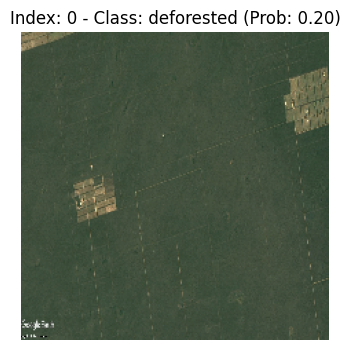

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


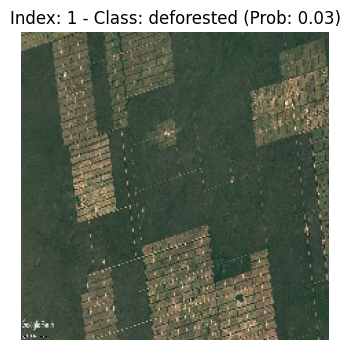

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


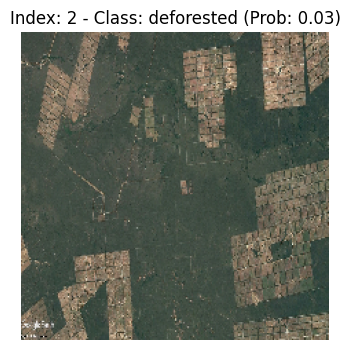

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


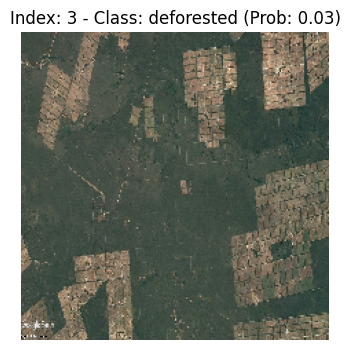

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


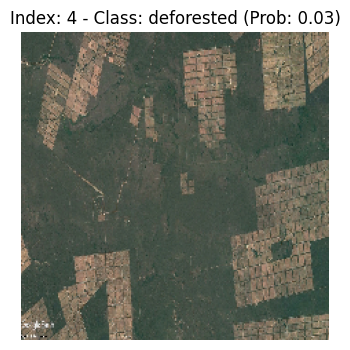

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


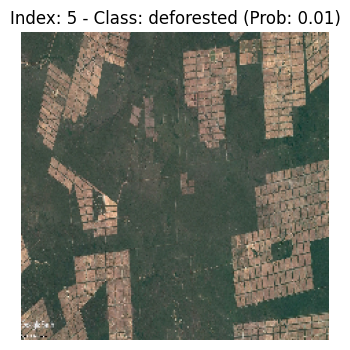

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


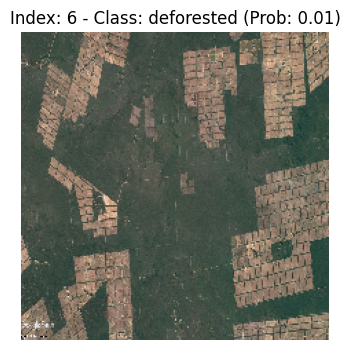

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


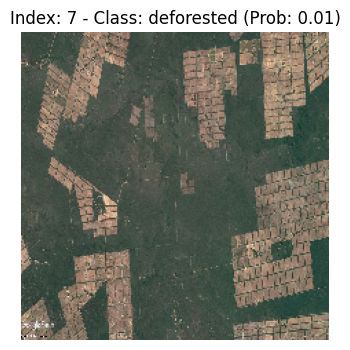

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


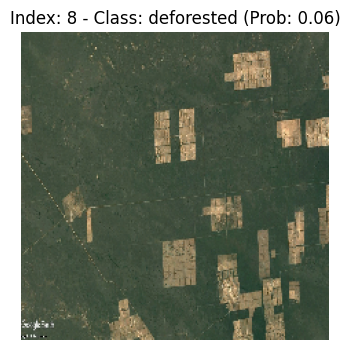

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


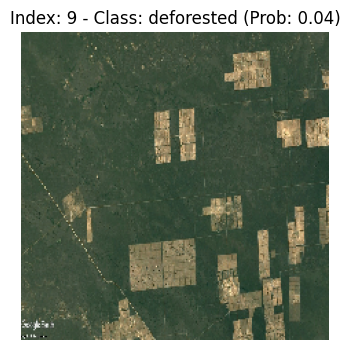

Finished displaying 10 deforested images.


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image


class_indices = test_generator.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda item: item[1])]


single_image_test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

single_image_test_generator.reset()

print(f"Using the function `predict_and_display_deforested` to display up to 10 images classified as '{class_names[class_indices['deforested']]}'.")
print("Note: Each deforested image found will be displayed in a separate plot window/inline figure as per the function's definition.")

displayed_deforested_count = 0
max_display = 10
images_to_process = single_image_test_generator.samples

for i in range(images_to_process):
    if displayed_deforested_count >= max_display:
        break

    filepath = single_image_test_generator.filepaths[i]

    if predict_and_display_deforested(filepath, model, IMG_WIDTH, IMG_HEIGHT, class_names, index=i):
        displayed_deforested_count += 1

if displayed_deforested_count == 0:
    print(f"No images classified as '{class_names[class_indices['deforested']]}' were found and displayed.")
else:
    print(f"Finished displaying {displayed_deforested_count} deforested images.")